In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-12-10 14:27:44.461027


In [10]:
from pathlib import Path
import sys
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns

In [34]:
plt.rcParams['figure.figsize'] = (3,3)
plt.rcParams["figure.dpi"] = 150

In [4]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

input_dir = BASE_DIR / "data/h5ad/export_04/04b_reclustered"
output_dir = BASE_DIR / "figures"

output_dir.mkdir(parents=True, exist_ok=True)

input_file = input_dir / "neurons-seurat.h5ad"

In [5]:
sc.settings.figdir = output_dir

In [108]:
adata = sc.read_h5ad(input_file)
adata

AnnData object with n_obs × n_vars = 22411 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'scanvi_labels', 'seurat_labels', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'predicti

In [171]:
print(f"Total cells: {adata.n_obs:,}")
print(f"Median transcripts per cell: {adata.obs['total_counts'].median():,.0f}")
print(f"Median detected genes per cell: {adata.obs['n_genes_by_counts'].median():,.0f}")

Total cells: 22,411
Median transcripts per cell: 1,789
Median detected genes per cell: 190


## Prepare data

In [109]:
adata.X = adata.layers['log1p'].copy()

In [110]:
def assign_cell_type_colors(adata, key="cell_type"):
    """Assigns a HUSL color palette to a categorical obs field."""
    adata.obs[key] = adata.obs[key].astype("category")
    num_categories = len(adata.obs[key].cat.categories)

    palette = sns.color_palette("husl", n_colors=num_categories)
    adata.uns[f"{key}_colors"] = [mcolors.to_hex(c) for c in palette]

    print(f"Assigned {num_categories} HUSL colors for `{key}`.")

assign_cell_type_colors(adata, key="seurat_labels")

Assigned 15 HUSL colors for `seurat_labels`.


In [162]:
adata.obs.EGFP_dTomato_dual_hi.value_counts()

EGFP_dTomato_dual_hi
False    22392
True        19
Name: count, dtype: int64

# UMAP

In [111]:
#sc.tl.umap(adata, min_dist= 0.4)

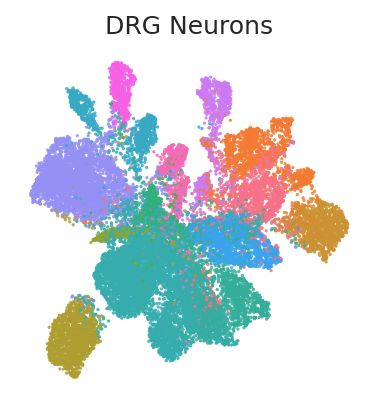

In [112]:
sc.pl.umap(adata, color = ['seurat_labels'], frameon = False, size = 10, alpha=0.85, title = 'DRG Neurons', legend_loc = 'none')

In [113]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_annotation_legend(adata, annotation, ncols=1, fontsize=12, title=None):
    """
    Standalone legend for a categorical annotation in adata.obs.
    
    Uses the colors stored in adata.uns[f"{annotation}_colors"].
    """

    cats = adata.obs[annotation].cat.categories
    colors = adata.uns[f"{annotation}_colors"]

    if len(cats) != len(colors):
        raise ValueError("Mismatch: categories and colors differ in length.")

    # Create patches
    handles = [
        mpatches.Patch(color=colors[i], label=cats[i])
        for i in range(len(cats))
    ]

    # Create figure
    fig, ax = plt.subplots(figsize=(2 + ncols*1.2, 0.4*len(cats)))
    ax.axis("off")

    # Plot legend
    legend = ax.legend(
        handles=handles,
        loc="center",
        ncol=ncols,
        frameon=False,
        fontsize=fontsize,
        #title=title if title else annotation,
        #title_fontsize=fontsize+1
    )

    plt.show()

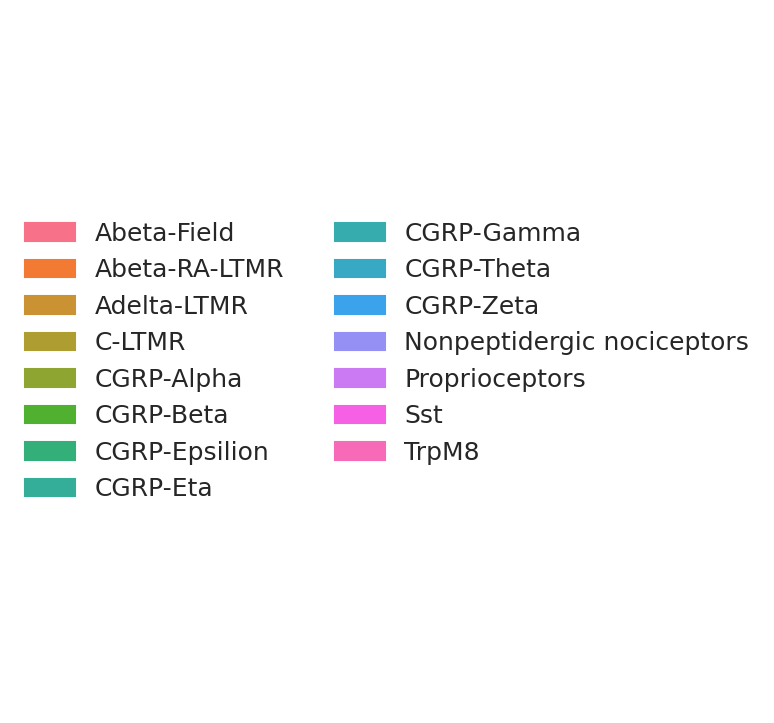

In [114]:
plot_annotation_legend(adata, "seurat_labels", ncols=2, fontsize=12)

In [115]:
bdata = adata.copy()

In [116]:
sc.tl.umap(bdata, min_dist= 0.3)

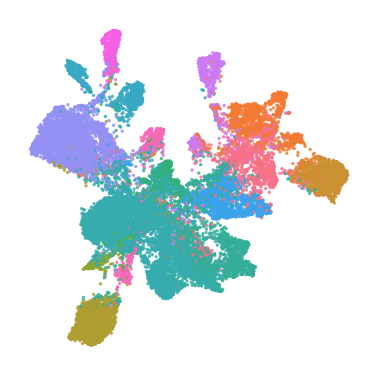

In [117]:
sc.pl.umap(bdata, color = ['seurat_labels'], frameon = False, size = 10, alpha=0.85, title = '', legend_loc = 'none')

In [169]:
def assign_cell_type_colors(adata, key="cell_type"):
    """Assigns a HUSL color palette to a categorical obs field."""
    adata.obs[key] = adata.obs[key].astype("category")
    num_categories = len(adata.obs[key].cat.categories)

    palette = sns.color_palette("tab20", n_colors=num_categories)
    adata.uns[f"{key}_colors"] = [mcolors.to_hex(c) for c in palette]

    print(f"Assigned {num_categories} HUSL colors for `{key}`.")

assign_cell_type_colors(bdata, key="seurat_labels")

Assigned 15 HUSL colors for `seurat_labels`.


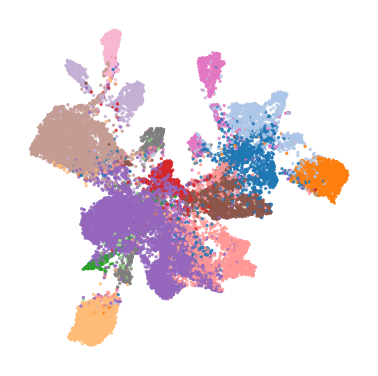

In [170]:
sc.pl.umap(bdata, color = ['seurat_labels'], frameon = False, size = 10, alpha=0.85, title = '', legend_loc = 'none')

# Barplot

In [118]:
adata

AnnData object with n_obs × n_vars = 22411 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'scanvi_labels', 'seurat_labels', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'predicti

In [159]:
def barplot_dual_distribution(
    adata,
    group_col="seurat_labels",
    dual_col="EGFP_dTomato_dual_hi",
    bar_color="black",
    figsize=(4,2),
    fontsize=11
):
    df = adata.obs[[group_col, dual_col]].copy()
    df[dual_col] = df[dual_col].astype(bool)
    df[group_col] = df[group_col].astype(str).replace("nan", "Unknown")

    # Count dual positives per group (correct)
    dual_counts = df.groupby(group_col)[dual_col].sum()

    total_dual = dual_counts.sum()

    # Correct percentage
    stats = (dual_counts / total_dual * 100).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(stats))
    ax.bar(x, stats.values, color=bar_color, alpha=0.9)

    # xticks
    ax.set_xticks(x)
    ax.set_xticklabels(stats.index, rotation=45, ha="right", fontsize=fontsize)

    # y-axis
    ax.set_ylim(0, 100)   # <-- force axis to show full 0–100%
    ax.set_ylabel("% of Double+ \nneurons", fontsize=fontsize)
    ax.set_xlabel("")

    # minimalist styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', length=0)

    plt.subplots_adjust(bottom=0.28)
    return fig

In [160]:
adata.obs.EGFP_dTomato_dual_hi.value_counts()

EGFP_dTomato_dual_hi
False    22392
True        19
Name: count, dtype: int64

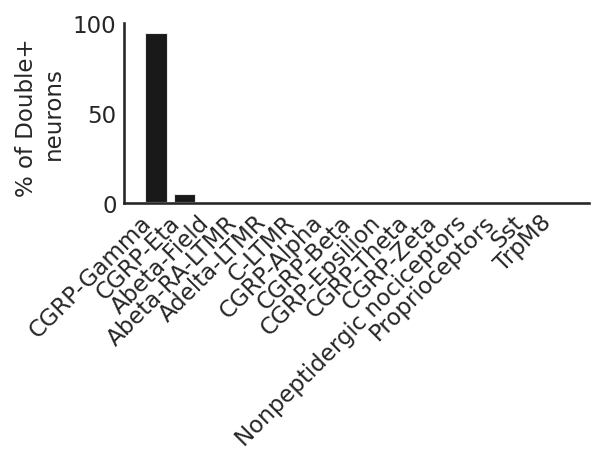

In [161]:
fig = barplot_dual_distribution(adata)

In [132]:
import pandas as pd
import numpy as np

def debug_dual_distribution(
    adata,
    group_col="seurat_labels",
    dual_col="EGFP_dTomato_dual_hi"
):
    df = adata.obs[[group_col, dual_col]].copy()

    # Force boolean for safety
    df[dual_col] = df[dual_col].astype(bool)

    # Ensure cluster labels are strings
    df[group_col] = df[group_col].astype(str).replace("nan", "Unknown")

    # Count dual-positive per group
    dual_counts = df.groupby(group_col)[dual_col].sum().sort_values(ascending=False)

    total_dual = dual_counts.sum()

    print("TOTAL dual-positive cells in dataset =", total_dual)
    print()

    # Compute percentages
    percent = (dual_counts / total_dual * 100)

    debug_table = pd.DataFrame({
        "dual_count": dual_counts,
        "percent_of_all_dual": percent,
        "cumulative_percent": percent.cumsum()
    })

    return debug_table

In [133]:
debug_dual_distribution(adata)

TOTAL dual-positive cells in dataset = 19



,dual_count,percent_of_all_dual,cumulative_percent
seurat_labels,,,
CGRP-Gamma,18,94.736842,94.736842
CGRP-Eta,1,5.263158,100.000000
Abeta-Field,0,0.000000,100.000000
Abeta-RA-LTMR,0,0.000000,100.000000
Adelta-LTMR,0,0.000000,100.000000
C-LTMR,0,0.000000,100.000000
CGRP-Alpha,0,0.000000,100.000000
CGRP-Beta,0,0.000000,100.000000
CGRP-Epsilion,0,0.000000,100.000000


# Thresholds

Need to map this to adata_ref to set the thresholds on the full dataset.

In [63]:
adata_ref_path = BASE_DIR / "data/h5ad/export_02/02b_leiden/adata-leiden-480.h5ad"

### Read and process adata

In [84]:
adata_ref = sc.read_h5ad(adata_ref_path)

In [85]:
adata.X = adata.layers['counts'].copy()
adata_ref.X = adata_ref.layers['counts'].copy()

In [86]:
adata_list = [adata, adata_ref]

for ad in adata_list:
    ad.var_names = ad.var_names.where(
        ad.var_names != "tdTomato_Seq2",
        "dTomato_Seq2"
    )

In [87]:
genes = ['EGFP_Seq1', 'dTomato_Seq2']

In [88]:
def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

# Raw counts for filtering
egfp_raw_all = to_dense(adata_ref[:, "EGFP_Seq1"].X)
td_raw_all   = to_dense(adata_ref[:, "dTomato_Seq2"].X)

# Filter to include only cells with >1 raw count in both genes
bg_filter = (egfp_raw_all > 1) & (td_raw_all > 1)

gauss_results = {}

# Fit a Gaussian distribution to filtered signal
for g in genes:
    x_raw_full = to_dense(adata_ref[:, g].X)
    x_raw = x_raw_full[bg_filter]

    # log1p transform
    x_log = np.log1p(x_raw)

    # Fit Gaussian
    mu = np.mean(x_log)
    sigma = np.std(x_log)

    # 99th percentile of Gaussian = mean + 2.326 * sd
    thr_log = mu + 2.326 * sigma

    # call positives
    hi_mask = np.zeros(adata_ref.n_obs, dtype=bool)
    hi_mask[bg_filter] = x_log > thr_log
    adata_ref.obs[f"{g}_hi"] = hi_mask

    gauss_results[g] = {
        "x_log": x_log,
        "thr_log": thr_log,
        "mu": mu,
        "sigma": sigma
    }

In [89]:
# Dual-high
adata_ref.obs['EGFP_dTomato_dual_hi'] = (
    adata_ref.obs['EGFP_Seq1_hi'] &
    adata_ref.obs['dTomato_Seq2_hi']
)

dual = adata_ref.obs['EGFP_dTomato_dual_hi'][bg_filter].values

# Extract for plotting
x_egfp_log = gauss_results["EGFP_Seq1"]["x_log"]
x_td_log   = gauss_results["dTomato_Seq2"]["x_log"]
thr_egfp_log = gauss_results["EGFP_Seq1"]["thr_log"]
thr_td_log   = gauss_results["dTomato_Seq2"]["thr_log"]

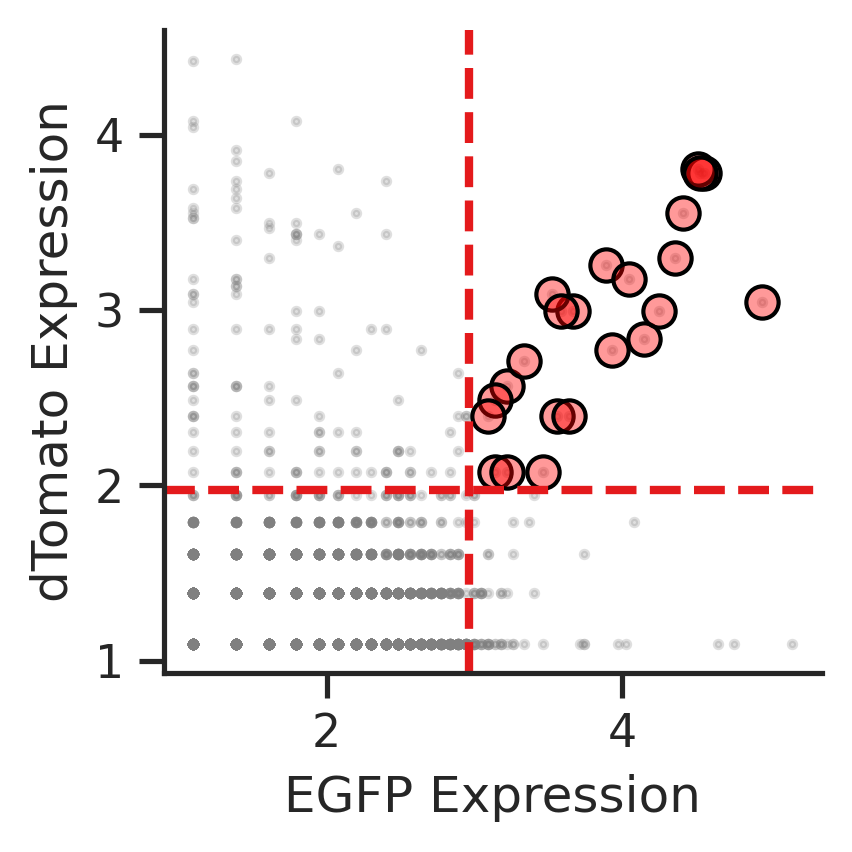

In [90]:
# Plot
sns.set_theme(style="ticks")

plt.figure(figsize=(3,3), dpi=300)
ax = plt.gca()

ax.scatter(x_egfp_log, x_td_log, s=3, color="gray", alpha=0.25)
ax.scatter(x_egfp_log[dual], x_td_log[dual],
           s=60, facecolors=(1,0,0,0.4), edgecolors="black")

ax.axvline(thr_egfp_log, color="#e41a1c", ls="--", lw=2)
ax.axhline(thr_td_log,   color="#e41a1c", ls="--", lw=2)

ax.set_xlabel("EGFP Expression")
ax.set_ylabel("dTomato Expression")
ax.set_title("")

sns.despine()
plt.tight_layout()
plt.show()

Common cells: 22411


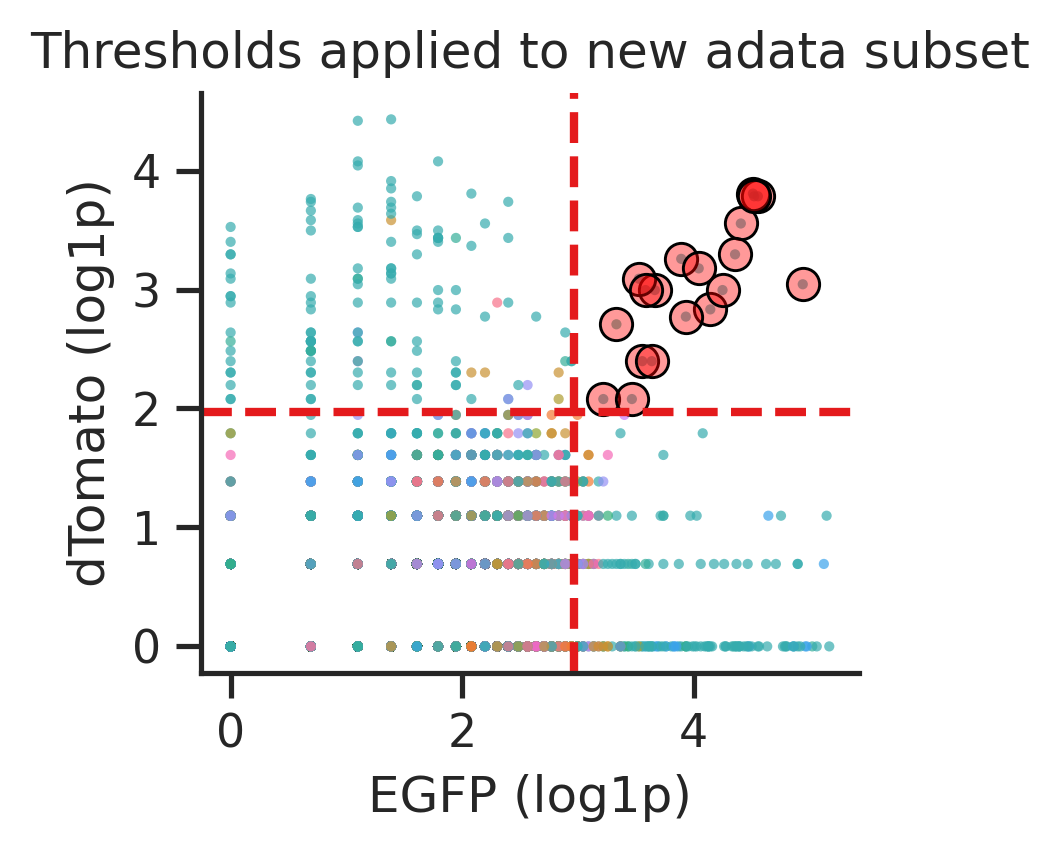

In [91]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Fix index mismatch ---
adata_ref.obs_names = adata_ref.obs_names.str.replace(r"-\d+$", "", regex=True)

# Helper
def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

# --- Match cells ---
common_cells = adata.obs_names.intersection(adata_ref.obs_names)
print("Common cells:", len(common_cells))

# --- Extract reporter expression from adata_ref ---
egfp_raw = to_dense(adata_ref[common_cells, "EGFP_Seq1"].X)
td_raw   = to_dense(adata_ref[common_cells, "dTomato_Seq2"].X)

x_egfp_log = np.log1p(egfp_raw)
x_td_log   = np.log1p(td_raw)

# --- Extract Seurat labels from new adata ---
labels = adata.obs.loc[common_cells, "seurat_labels"]

# Colors for all points
if "seurat_labels_colors" in adata.uns:
    label_colors = dict(zip(
        adata.obs["seurat_labels"].cat.categories,
        adata.uns["seurat_labels_colors"]
    ))
    point_colors = labels.map(label_colors)
else:
    point_colors = None

# --- Dual-high annotation from new adata ---
dual_mask = adata.obs.loc[common_cells, "EGFP_dTomato_dual_hi"].values

# --- Plot ---
sns.set_theme(style="ticks")

plt.figure(figsize=(3,3), dpi=300)
ax = plt.gca()

# Plot ALL points colored by Seurat labels
ax.scatter(
    x_egfp_log,
    x_td_log,
    s=6,
    c=point_colors,
    alpha=0.7,
    linewidths=0
)

# Overlay DUAL-HIGH cells with larger points like your example
ax.scatter(
    x_egfp_log[dual_mask],
    x_td_log[dual_mask],
    s=60,
    facecolors=(1,0,0,0.4),
    edgecolors="black",
    linewidths=0.7
)

# Thresholds
ax.axvline(thr_egfp_log, color="#e41a1c", ls="--", lw=2)
ax.axhline(thr_td_log,   color="#e41a1c", ls="--", lw=2)

# Labels
ax.set_xlabel("EGFP (log1p)")
ax.set_ylabel("dTomato (log1p)")
ax.set_title("Thresholds applied to new adata subset")

sns.despine()
plt.tight_layout()
plt.show()

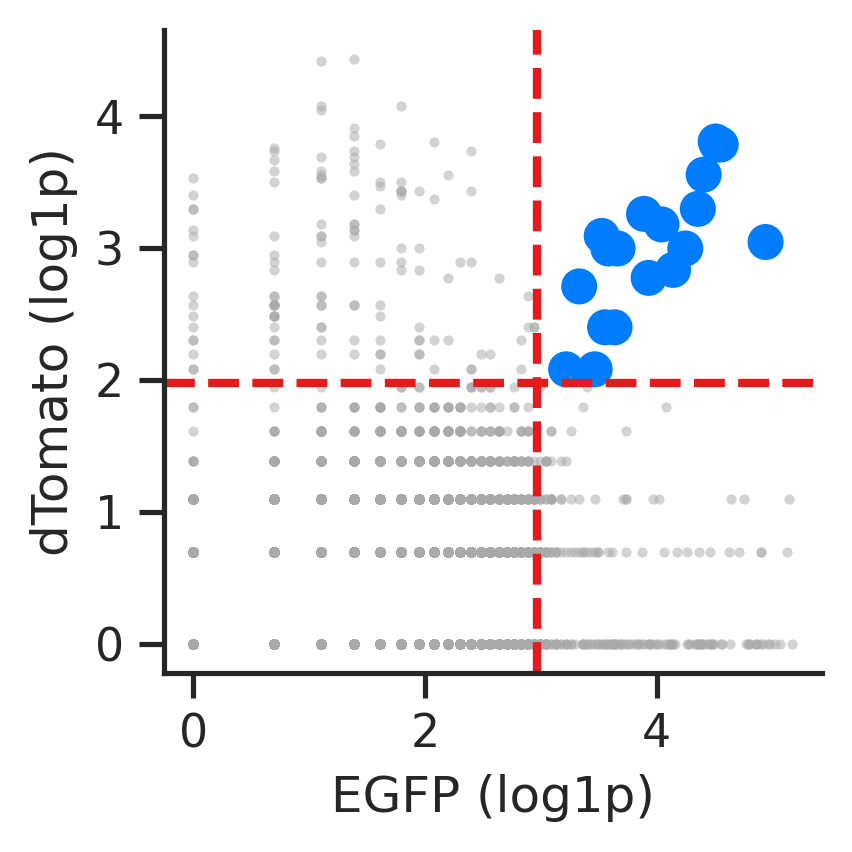

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# --- Plot ---
sns.set_theme(style="ticks")
plt.figure(figsize=(3,3), dpi=300)
ax = plt.gca()

# ---- Base layer: ALL non-dual-hi cells in gray ----
ax.scatter(
    x_egfp_log[~dual_mask],
    x_td_log[~dual_mask],
    s=6,
    color="darkgrey",
    alpha=0.5,
    linewidths=0
)

# ---- Dual-positive cells in bright blue, large, alpha fill, solid edge ----
bright_blue = "#007CFF"       # vivid blue
fill_alpha  = 0.55            # transparency for fill

dual_fill_rgba = (*mcolors.to_rgb(bright_blue), fill_alpha)

ax.scatter(
    x_egfp_log[dual_mask],
    x_td_log[dual_mask],
    s=60,
    c=[dual_fill_rgba] * dual_mask.sum(),  # blue fill w/ alpha
    edgecolors=bright_blue,                 # full-opacity outline
    linewidths=0.9,
    alpha=1.0                               # keep outline opaque
)

# ---- Threshold lines ----
ax.axvline(thr_egfp_log, color="#e41a1c", ls="--", lw=2)
ax.axhline(thr_td_log,   color="#e41a1c", ls="--", lw=2)

ax.set_xlabel("EGFP (log1p)")
ax.set_ylabel("dTomato (log1p)")
ax.set_title("")

sns.despine()
plt.tight_layout()
plt.show()

In [74]:
for ad in adata_list:
    mask = ad.obs["EGFP_dTomato_dual_hi"].fillna(False)
    dual_barcodes = ad.obs.index[mask].tolist()

    print("\nDual-positive barcodes:")
    for bc in dual_barcodes:
        print(bc)
    print(f"\nTotal: {len(dual_barcodes)} barcodes printed.")


Dual-positive barcodes:
bpoikicj-1
cbhmmeof-1
bmjgagok-1
ijnggkoc-1
llknggjo-1
llmfnafp-1
llmgffik-1
jjmnhibg-1
aefmnmje-1
ajnphbmj-1
eckajpnf-1
akcoadof-1
bgmdeeeb-1
hjjgalia-1
hjjkhdhk-1
mnhcfodp-1
aapmhgin-1
ebnbhhob-1
ikjbpmlk-1

Total: 19 barcodes printed.

Dual-positive barcodes:
apeeemip-1-0
bpoikicj-1-0
cbhmmeof-1-0
bmjgagok-1-1
ijnggkoc-1-1
llknggjo-1-1
llmfnafp-1-1
llmgffik-1-1
jjmnhibg-1-2
jkabbhfm-1-2
aefmnmje-1-3
mklknhcg-1-3
ajnphbmj-1-6
eckajpnf-1-6
akcoadof-1-7
bgmdeeeb-1-7
hjjgalia-1-7
hjjkhdhk-1-7
mnhcfodp-1-7
aapmhgin-1-9
ebnbhhob-1-10
ebnfggjb-1-10
ikjbpmlk-1-10

Total: 23 barcodes printed.


In [164]:
# Boolean masks
egfp = adata.obs["EGFP_Seq1_hi"].astype(bool)
dtom = adata.obs["dTomato_Seq2_hi"].astype(bool)
dual = adata.obs["EGFP_dTomato_dual_hi"].astype(bool)

egfp_single = egfp & ~dtom
dtom_single = dtom & ~egfp
dual_pos    = dual

# Build a small table
df = pd.DataFrame({
    "barcode": adata.obs.index,
    "seurat_label": adata.obs["seurat_labels"],
    "scanvi_label": adata.obs["scanvi_labels"],
    "sample_id": adata.obs["sample_id"],
    "confidence": adata.obs["confidence"],
    "EGFP_single": egfp_single.values,
    "dTom_single": dtom_single.values,
    "Dual_positive": dual_pos.values,
})

# Summary
df[df["Dual_positive"]][["barcode", "sample_id", "seurat_label", "scanvi_label", "confidence"]]

,barcode,sample_id,seurat_label,scanvi_label,confidence
bpoikicj-1,bpoikicj-1,TMA00304,CGRP-Gamma,CGRP-Gamma,High
cbhmmeof-1,cbhmmeof-1,TMA00304,CGRP-Gamma,CGRP-Gamma,High
bmjgagok-1,bmjgagok-1,TMA00306,CGRP-Gamma,CGRP-Gamma,High
ijnggkoc-1,ijnggkoc-1,TMA00306,CGRP-Gamma,CGRP-Gamma,High
llknggjo-1,llknggjo-1,TMA00306,CGRP-Gamma,CGRP-Gamma,High
llmfnafp-1,llmfnafp-1,TMA00306,CGRP-Gamma,CGRP-Gamma,High
llmgffik-1,llmgffik-1,TMA00306,CGRP-Gamma,CGRP-Gamma,High
jjmnhibg-1,jjmnhibg-1,TMA00313,CGRP-Gamma,CGRP-Gamma,NaN
aefmnmje-1,aefmnmje-1,TMA00311,CGRP-Gamma,CGRP-Gamma,High
ajnphbmj-1,ajnphbmj-1,TMA00310,CGRP-Gamma,CGRP-Gamma,NaN
